# Clase 04 — Análisis exploratorio multivariado y PCA del Wine dataset

**Dataset:** [Wine recognition dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-recognition-dataset) (UCI / scikit-learn) — análisis químico de 178 vinos de una misma región de Italia, provenientes de 3 cultivares distintos (`class_0`, `class_1`, `class_2`), con 13 variables continuas por vino.

Se replica sobre este dataset el análisis hecho en clase con Iris (`EDA Iris.ipynb`).

## Actividades

1. Cargar el dataset y ver la distribución de cada variable por cultivar.
2. Codificar el cultivar con variables indicadoras.
3. Calcular vector de medias, desvíos, matriz de covarianza y matriz de correlación.
4. Graficar la matriz de dispersión multivariante.
5. Hacer un análisis de componentes principales (PCA) y analizar los datos en el espacio reducido.

In [1]:
import sys
from pathlib import Path

# Permite importar el paquete `src` de la clase (la carpeta que contiene este notebook).
CLASE_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src").is_dir())
if str(CLASE_ROOT) not in sys.path:
    sys.path.insert(0, str(CLASE_ROOT))

import pandas as pd

from src import plots
from src.config import ANALYSIS_COLUMNS, FEATURES, PCA_SCORES_CSV, TARGET
from src.data import add_class_dummies, load_wine_df
from src.pca import rank_features_by_class, run_pca

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
plots.set_style()

## 1. Carga del dataset y distribución univariante

`load_wine_df` arma el DataFrame a partir de `sklearn.datasets.load_wine` y deja una copia en `data/raw/wine.csv`.

In [2]:
wine = load_wine_df()

print(f"Filas: {wine.shape[0]}, columnas: {wine.shape[1]}")
print(f"Valores nulos: {wine.isna().sum().sum()}")
print(wine[TARGET].value_counts().sort_index())
wine.head()

Filas: 178, columnas: 14
Valores nulos: 0
cultivar
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


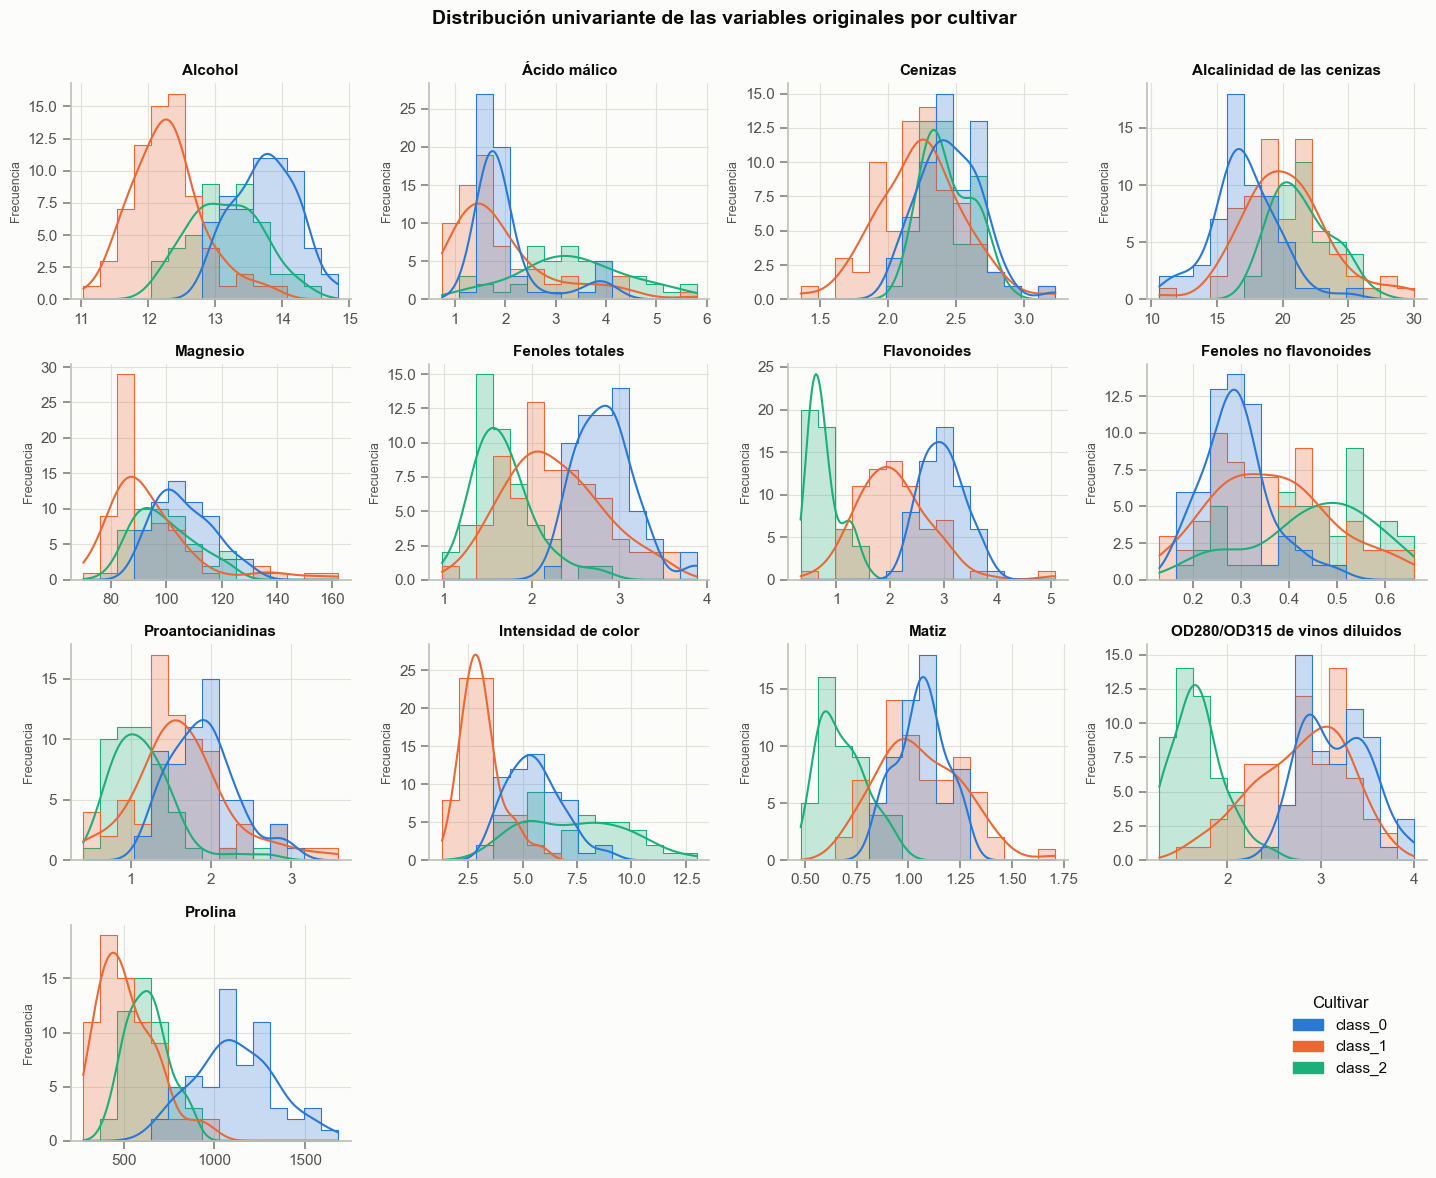

In [3]:
fig = plots.plot_distributions(wine, FEATURES)
plots.save_figure(fig, "distribuciones")

Ya en el análisis univariante se ve que ninguna variable separa sola a los tres cultivares, pero varias separan a uno del resto: `proline` y `alcohol` distinguen a `class_0`, `flavanoids`, `hue` y `od280_od315` aíslan a `class_2` (valores bajos), y `color_intensity` deja a `class_1` en el extremo inferior. Otras, como `ash` o `magnesium`, se superponen casi por completo.

## 2. Codificación indicadora del cultivar

Igual que con Iris, la clase se codifica con variables indicadoras (dummy) para poder incluirla en las matrices de covarianza y correlación. Con 3 cultivares alcanzan 2 indicadoras: `x_class_0` y `x_class_1` (`class_2` queda como categoría de referencia).

In [4]:
wine_codificado = add_class_dummies(wine)
datos_analisis = wine_codificado[ANALYSIS_COLUMNS]

datos_analisis.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline,x_class_0,x_class_1
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,1,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,1,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,1,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,1,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,1,0


## 3. Medias, desvíos, covarianza y correlación

In [5]:
vector_medias = datos_analisis.mean()
print("--- Vector de medias ---")
print(vector_medias.round(3))

--- Vector de medias ---
alcohol                  13.001
malic_acid                2.336
ash                       2.367
alcalinity_of_ash        19.495
magnesium                99.742
total_phenols             2.295
flavanoids                2.029
nonflavanoid_phenols      0.362
proanthocyanins           1.591
color_intensity           5.058
hue                       0.957
od280_od315               2.612
proline                 746.893
x_class_0                 0.331
x_class_1                 0.399
dtype: float64


In [6]:
# Desvíos: cada observación menos el vector de medias (datos centrados).
desvios = datos_analisis - vector_medias
desvios.round(3).head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline,x_class_0,x_class_1
0,1.229,-0.626,0.063,-3.895,27.258,0.505,1.031,-0.082,0.699,0.582,0.083,1.308,318.107,0.669,-0.399
1,0.199,-0.556,-0.227,-8.295,0.258,0.355,0.731,-0.102,-0.311,-0.678,0.093,0.788,303.107,0.669,-0.399
2,0.159,0.024,0.303,-0.895,1.258,0.505,1.211,-0.062,1.219,0.622,0.073,0.558,438.107,0.669,-0.399
3,1.369,-0.386,0.133,-2.695,13.258,1.555,1.461,-0.122,0.589,2.742,-0.097,0.838,733.107,0.669,-0.399
4,0.239,0.254,0.503,1.505,18.258,0.505,0.661,0.028,0.229,-0.738,0.083,0.318,-11.893,0.669,-0.399


In [7]:
matriz_cov = datos_analisis.cov()
print("--- Matriz de covarianza (redondeada a 3 decimales) ---")
matriz_cov.round(3)

--- Matriz de covarianza (redondeada a 3 decimales) ---


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline,x_class_0,x_class_1
alcohol,0.659,0.086,0.047,-0.841,3.140,0.147,0.192,-0.016,0.064,1.028,-0.013,0.042,164.567,0.248,-0.290
malic_acid,0.086,1.248,0.050,1.076,-0.871,-0.234,-0.459,0.041,-0.141,0.645,-0.143,-0.292,-67.549,-0.109,-0.162
ash,0.047,0.050,0.075,0.406,1.123,0.022,0.032,0.006,0.002,0.165,-0.005,0.001,19.320,0.030,-0.049
alcalinity_of_ash,-0.841,1.076,0.406,11.153,-3.975,-0.671,-1.172,0.150,-0.377,0.145,-0.209,-0.656,-463.355,-0.819,0.298
magnesium,3.140,-0.871,1.123,-3.975,203.989,1.916,2.793,-0.456,1.933,6.621,0.181,0.669,1769.159,2.199,-2.083
total_phenols,0.147,-0.234,0.022,-0.671,1.916,0.392,0.540,-0.035,0.219,-0.080,0.062,0.311,98.171,0.182,-0.015
flavanoids,0.192,-0.459,0.032,-1.172,2.793,0.540,0.998,-0.067,0.373,-0.399,0.124,0.558,155.447,0.318,0.021
nonflavanoid_phenols,-0.016,0.041,0.006,0.150,-0.456,-0.035,-0.067,0.015,-0.026,0.040,-0.007,-0.044,-12.204,-0.024,0.001
proanthocyanins,0.064,-0.141,0.002,-0.377,1.933,0.219,0.373,-0.026,0.328,-0.034,0.039,0.211,59.554,0.103,0.016
color_intensity,1.028,0.645,0.165,0.145,6.621,-0.080,-0.399,0.040,-0.034,5.374,-0.277,-0.706,230.767,0.157,-0.791


Las variables están en escalas muy distintas: la varianza de `proline` (del orden de 10⁵) es varios órdenes de magnitud mayor que la de `hue` o `nonflavanoid_phenols` (del orden de 10⁻²). La matriz de covarianza queda dominada por `proline` y `magnesium`, así que para comparar relaciones entre variables conviene la matriz de correlación, y para el PCA hay que estandarizar.

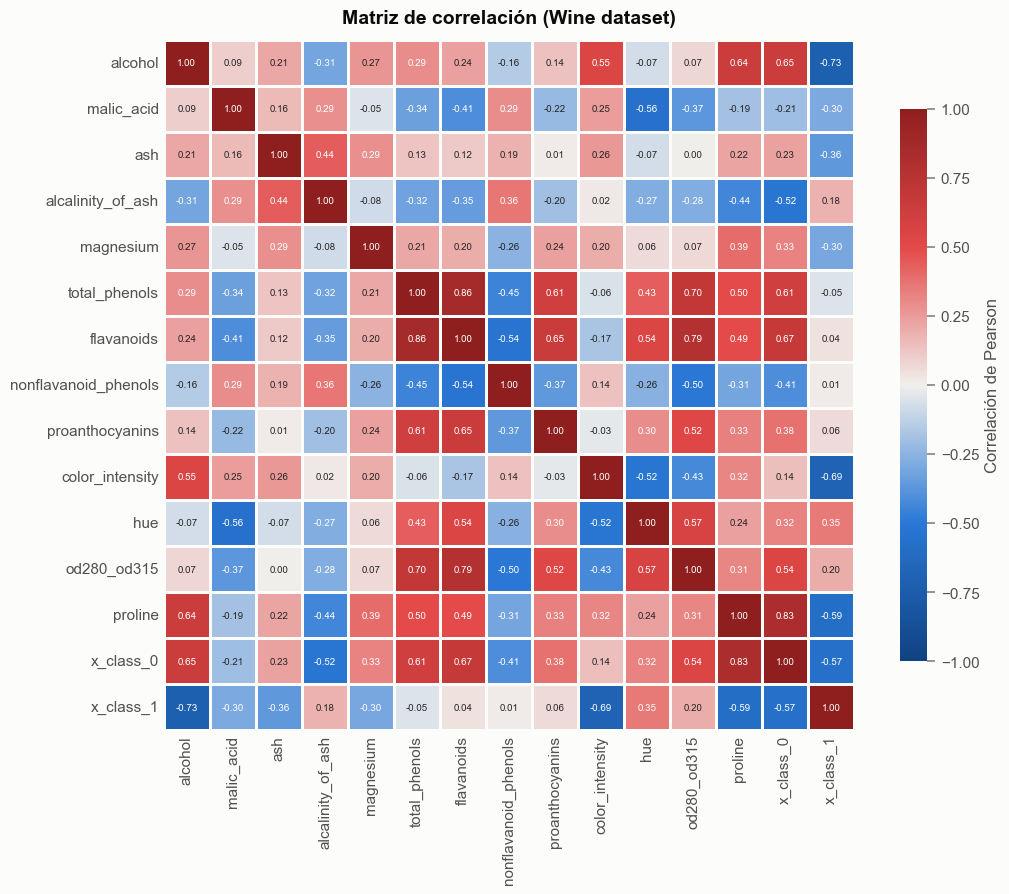

In [8]:
matriz_cor = datos_analisis.corr()

fig = plots.plot_correlation_heatmap(matriz_cor)
plots.save_figure(fig, "heatmap_correl")

- El bloque de compuestos fenólicos está fuertemente correlacionado: `total_phenols`–`flavanoids` (0,86), `flavanoids`–`od280_od315` (0,79), `total_phenols`–`od280_od315` (0,70). Miden en buena parte lo mismo.
- `alcohol` y `proline` van juntas (0,64), y `hue` se opone a `malic_acid` (−0,56) y a `color_intensity` (−0,52).
- Las indicadoras muestran qué variables identifican a cada cultivar: `x_class_0` correlaciona con `proline` (0,83) y `flavanoids` (0,67); `x_class_1` lo hace negativamente con `alcohol` (−0,73) y `color_intensity` (−0,69).

## 4. Matriz de dispersión multivariante

Con 13 variables la matriz completa tendría 169 paneles. Se grafican las 5 variables que más separan a los cultivares, ordenándolas por el estadístico F de un ANOVA de un factor (variabilidad entre cultivares sobre variabilidad dentro de cada cultivar).

In [9]:
ranking = rank_features_by_class(wine[FEATURES], wine[TARGET])
ranking.round(1)

flavanoids              233.9
proline                 207.9
od280_od315             190.0
alcohol                 135.1
color_intensity         120.7
hue                     101.3
total_phenols            93.7
malic_acid               36.9
alcalinity_of_ash        35.8
proanthocyanins          30.3
nonflavanoid_phenols     27.6
ash                      13.3
magnesium                12.4
Name: F, dtype: float64

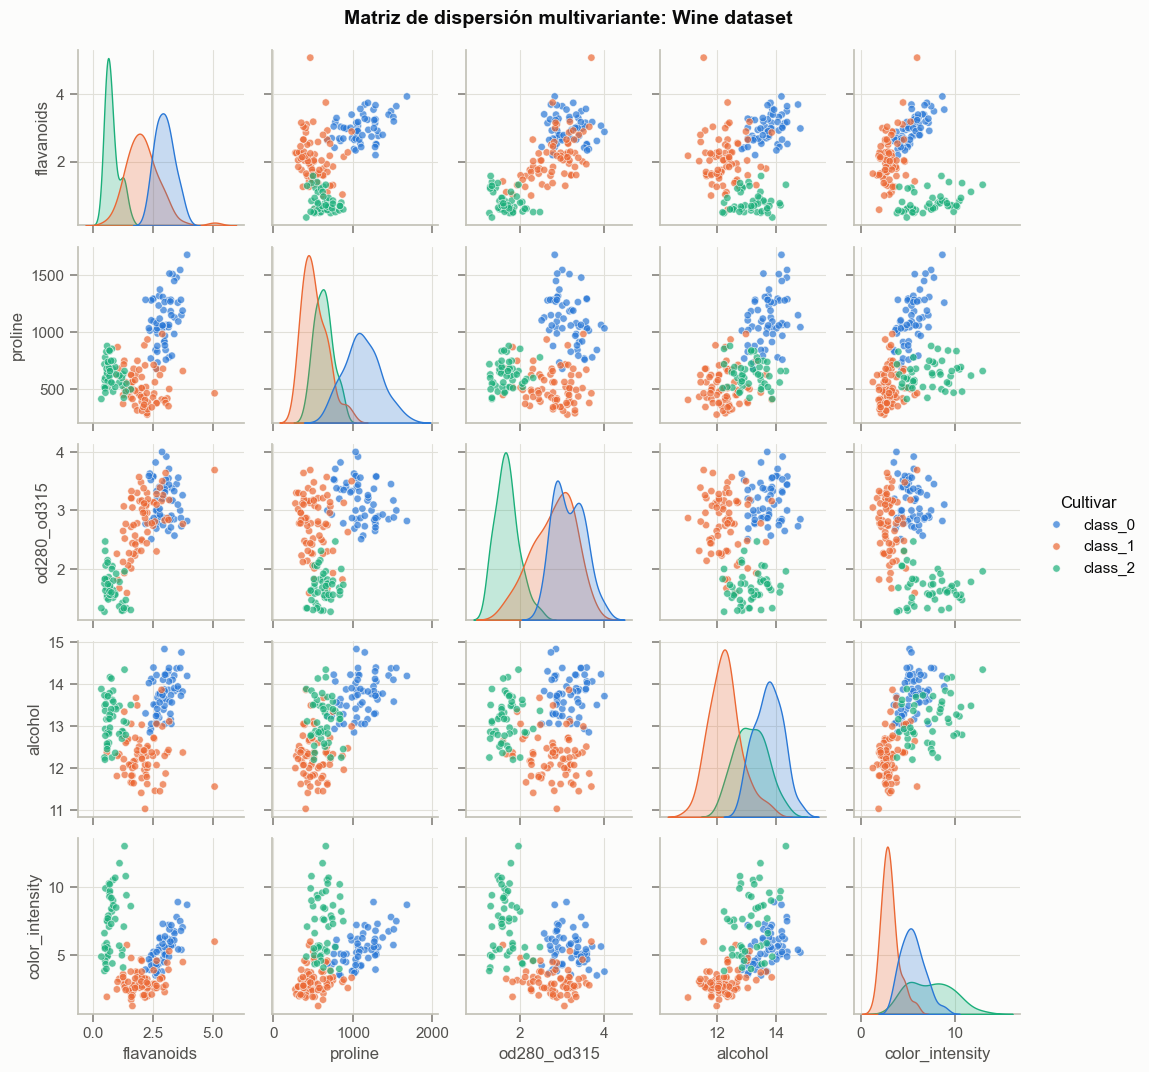

In [10]:
fig = plots.plot_pairplot(wine, list(ranking.index[:5]))
plots.save_figure(fig, "pairplot")

De a pares la separación ya es mucho más clara que variable por variable: por ejemplo `flavanoids` vs `color_intensity` o `proline` vs `od280_od315` dejan a los tres cultivares en regiones casi disjuntas.

# Análisis de componentes principales

Se estandarizan las variables (z-score), de modo que el PCA diagonaliza la matriz de correlación, y se usan las mismas columnas que en el análisis anterior: las 13 variables químicas más las 2 indicadoras.

In [11]:
pca = run_pca(datos_analisis)

pca.variance_table().round(4)

,autovalor,var_explicada,var_acumulada
PC1,5.3949,0.3576,0.3576
PC2,3.4797,0.2307,0.5883
PC3,1.4799,0.0981,0.6864
PC4,0.9435,0.0625,0.7490
PC5,0.8957,0.0594,0.8083
PC6,0.6991,0.0463,0.8547
PC7,0.5571,0.0369,0.8916
PC8,0.3516,0.0233,0.9149
PC9,0.3206,0.0213,0.9362
PC10,0.2616,0.0173,0.9535


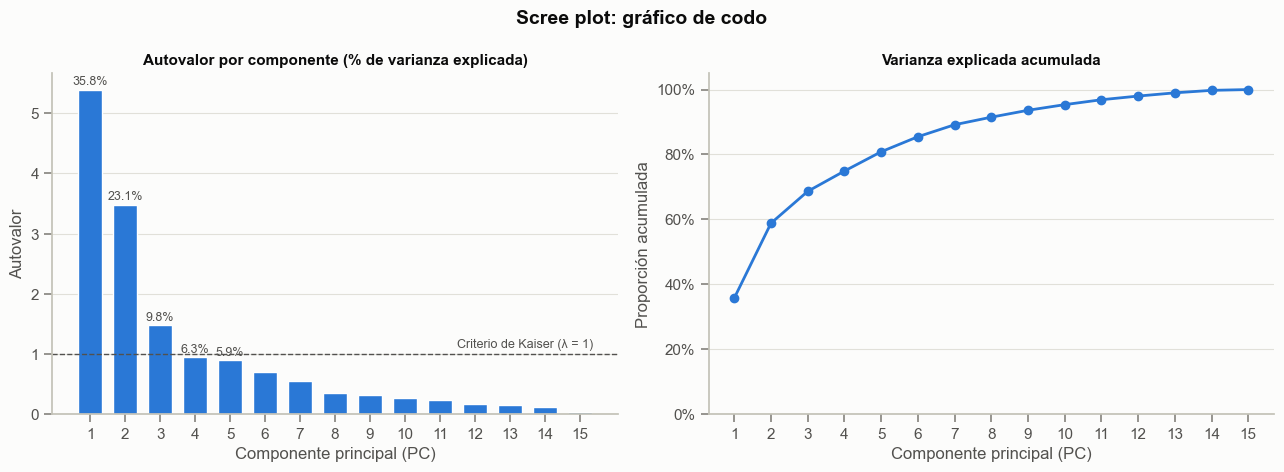

In [12]:
fig = plots.plot_scree(pca.eigenvalues, pca.var_exp)
plots.save_figure(fig, "scree_plot")

Por criterio de Kaiser se retienen las componentes 1, 2 y 3, que tienen autovalores mayores a 1 (5,39, 3,48 y 1,48) y acumulan el 68,6% de la varianza. La cuarta (0,94) queda apenas por debajo del corte. A diferencia de Iris, donde dos componentes alcanzaban, acá el plano PC1–PC2 retiene el 58,8%.

In [13]:
# Loadings: correlación de cada variable original con las componentes retenidas.
pca.loadings[["PC1", "PC2", "PC3"]].round(3)

,PC1,PC2,PC3
alcohol,0.478,-0.708,-0.166
malic_acid,-0.444,-0.455,0.136
ash,0.091,-0.441,0.789
alcalinity_of_ash,-0.545,-0.008,0.729
magnesium,0.368,-0.333,0.238
total_phenols,0.842,0.114,0.204
flavanoids,0.891,0.223,0.194
nonflavanoid_phenols,-0.616,-0.173,0.188
proanthocyanins,0.642,0.151,0.223
color_intensity,-0.036,-0.835,-0.057


- **PC1** es el eje fenólico: pesan positivamente `flavanoids` (0,89), `total_phenols` (0,84), `od280_od315` (0,75) y `proline` (0,75), y negativamente `nonflavanoid_phenols` (−0,62) y `alcalinity_of_ash` (−0,55). Va de la mano de `x_class_0` (0,86).
- **PC2** opone `color_intensity` (−0,84) y `alcohol` (−0,71) a `hue` (0,55): vinos claros y de poco alcohol arriba. Es prácticamente la indicadora `x_class_1` (0,91).
- **PC3** recoge las cenizas: `ash` (0,79) y `alcalinity_of_ash` (0,73), que casi no aportan a las dos primeras ni distinguen cultivares.

# Analizamos datos en espacio reducido R2

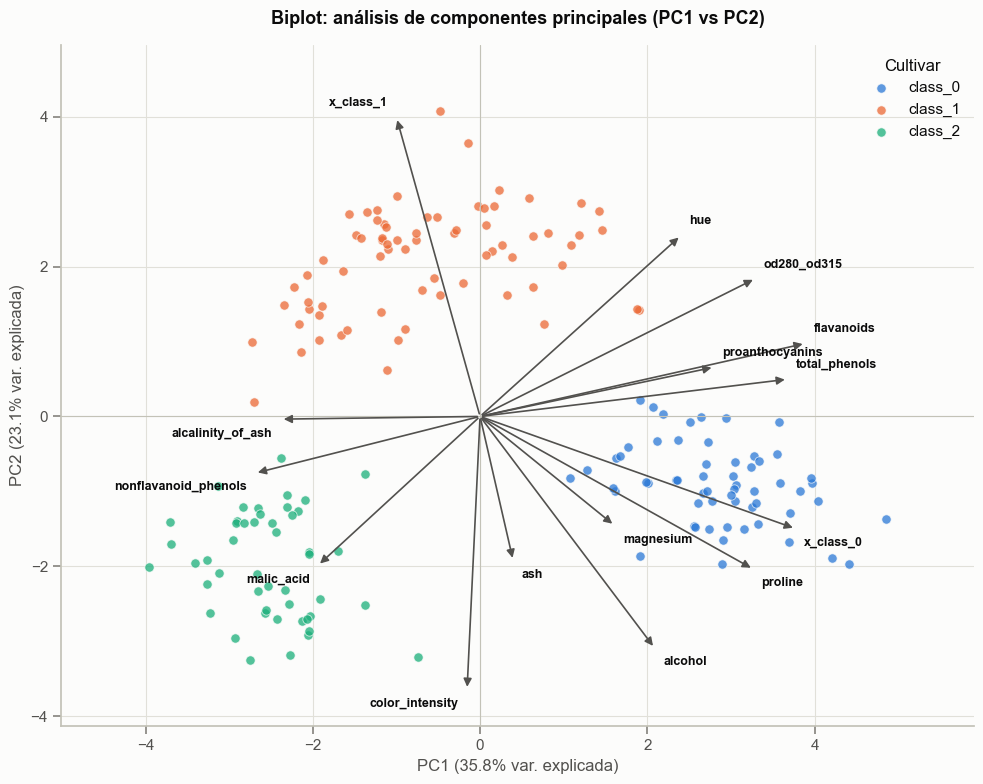

In [14]:
fig = plots.plot_biplot(pca.scores, pca.loadings, wine[TARGET], pca.var_exp)
plots.save_figure(fig, "biplot")

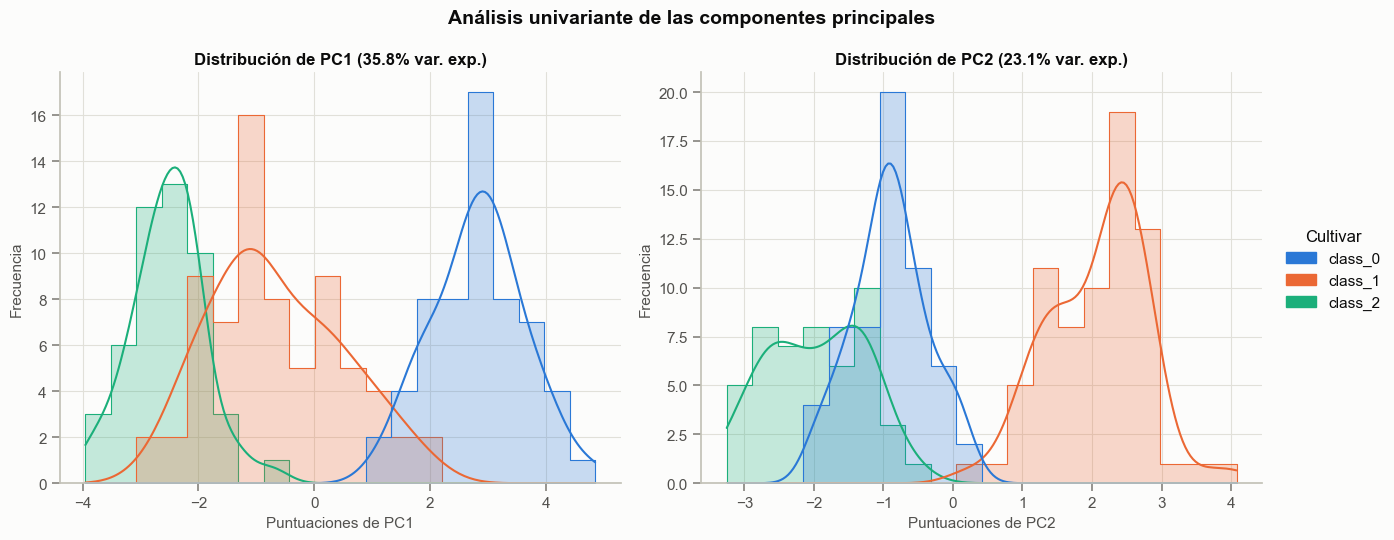

In [15]:
fig = plots.plot_pc_histograms(pca.scores, wine[TARGET], pca.var_exp)
plots.save_figure(fig, "histogramas_pc1_pc2")

In [16]:
pca.scores[["PC1", "PC2"]].groupby(wine[TARGET], observed=True).mean().round(2)

,PC1,PC2
cultivar,,
class_0,2.83,-0.90
class_1,-0.65,2.08
class_2,-2.52,-1.97


En el plano PC1–PC2 los tres cultivares forman grupos bien separados. PC1 ordena `class_2` → `class_1` → `class_0` (medias −2,52, −0,65 y 2,83), y PC2 despega a `class_1` (media 2,08) de los otros dos (−0,90 y −1,97). Ninguna de las dos componentes alcanza por sí sola —los histogramas se solapan en ambas—, pero juntas separan los tres grupos.